In [ ]:
#@title Copyright 2023 Google LLC. Double-click here for license information.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Colabs

Machine Learning Crash Course uses Colaboratories (Colabs) for all programming exercises. Colab is Google's implementation of [Jupyter Notebook](https://jupyter.org/). For more information about Colabs and how to use them, go to [Welcome to Colaboratory](https://research.google.com/colaboratory).

# Linear Regression
In this Colab you will use a real dataset to train a model to predict the fare of a taxi ride in Chicago, Illinois.

## Learning Objectives
After completing this Colab, you'll be able to:

  * Read a .csv file into a [pandas](https://developers.google.com/machine-learning/glossary/#pandas) DataFrame.
  * Explore a [dataset](https://developers.google.com/machine-learning/glossary/#data_set) with Python visualization libraries.
  * Experiment with different [features](https://developers.google.com/machine-learning/glossary/#feature) to build a linear regression model.
  * Tune the model's [hyperparameters](https://developers.google.com/machine-learning/glossary/#hyperparameter).
  * Compare training runs using [root mean squared error](https://developers.google.com/machine-learning/glossary/#root-mean-squared-error-rmse) and [loss curves](https://developers.google.com/machine-learning/glossary/#loss-curve).

## Dataset Description
The [dataset for this exercise](https://storage.mtls.cloud.google.com/mlcc-nextgen-internal/chicago_taxi_train.csv) is derived from the [City of Chicago Taxi Trips dataset](https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew). The data for this exercise is a subset of the Taxi Trips data, and focuses on a two-day period in May of 2022.

# Part 1 - Setup Exercise


---



## Load required modules

This exercise depends on several Python libraries to help with data manipulation, machine learning tasks, and data visualization.

**Instructions**
1. Run the **Install required libraries** code cell (below).
1. Run the **Load dependencies** code cell (below).

In [ ]:
#@title Install required libraries

!pip install numpy~=2.0.0
!pip install matplotlib~=3.10.0
!pip install pandas~=2.2.0
!pip install tensorflow~=2.18.0
!pip install keras~=3.8.0
!pip install yahoo_fin yfinance
!!pip install schedule

print('\n\nAll requirements successfully installed.')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.9/82.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 7.3 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6047 sha256=0e30408f7e0b1b4e16f0728091ec38ef324477b90230c4e11e468a457d38b7d6
  Stored in directory: /root/.cache/pip/wheels/3b/25/2a/105d6a15df6914f4d15047691c6c28f9052cc1173e40285d03
Successfully built sgmllib3k
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
  Attempting uninstal



All requirements successfully installed.


In [ ]:
#@title Code - Load dependencies

#general
import io

# data
import numpy as np
import pandas as pd
import yfinance as yf

# machine learning
import keras

# data visualization
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import seaborn as sns

## Load the dataset


The following code cell loads the dataset and creates a pandas DataFrame.

You can think of a DataFrame like a spreadsheet with rows and columns. The rows represent individual data examples, and the columns represent the attributes associated with each example.

In [ ]:
import yfinance as yf

# Fetch Bitcoin data from Yahoo Finance
btc = yf.Ticker("BTC-USD")
btc_price = btc.history(period="1d")["Close"].iloc[-1]

print(f"Current Bitcoin Price: ${btc_price:.2f}")

Current Bitcoin Price: $85101.85


## Update the dataframe

The following code cell updates the DataFrame to use only specific columns from the dataset.

Notice that that output shows just a sample of the dataset, but there should be enough information for you to identify the features associated with the dataset, and have a look at the actual data for a few examples.

In [ ]:
# #@title Code - Read dataset

# Updates dataframe to use specific columns.
training_df = btc.history(period="7d", interval="15m")[['High', 'Low', 'Close', 'Volume']]
training_df['Datetime'] = training_df.index

print('Read dataset completed successfully.')
print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.head(200)

# import yfinance as yf

# # Fetch historical 15-minute interval data for Bitcoin
# btc = yf.Ticker("BTC-USD")
# btc_data = btc.history(period="7d", interval="15m")  # Change period as needed

# # Display the historical data
# print(btc_data)

Read dataset completed successfully.
Total number of rows: 638




,High,Low,Close,Volume,Datetime
Datetime,,,,,
2025-03-17 00:00:00+00:00,82801.703125,82567.265625,82771.109375,153251840,2025-03-17 00:00:00+00:00
2025-03-17 00:15:00+00:00,82832.937500,82755.789062,82832.937500,163870720,2025-03-17 00:15:00+00:00
2025-03-17 00:30:00+00:00,82951.078125,82834.039062,82886.664062,136116224,2025-03-17 00:30:00+00:00
2025-03-17 00:45:00+00:00,83094.203125,82939.093750,83053.023438,115116032,2025-03-17 00:45:00+00:00
2025-03-17 01:00:00+00:00,83210.367188,82836.250000,82836.250000,140417024,2025-03-17 01:00:00+00:00
...,...,...,...,...,...
2025-03-19 00:45:00+00:00,83204.242188,82977.679688,82977.679688,25518080,2025-03-19 00:45:00+00:00
2025-03-19 01:00:00+00:00,83149.445312,82892.531250,82904.882812,221839360,2025-03-19 01:00:00+00:00
2025-03-19 01:15:00+00:00,82920.781250,82815.093750,82821.273438,425725952,2025-03-19 01:15:00+00:00


# Part 2 - Dataset Exploration


---



## View dataset statistics

A large part of most machine learning projects is getting to know your data. In this step, you will use the ``DataFrame.describe`` method to view descriptive statistics about the dataset and answer some important questions about the data.

**Instructions**
1. Run the **View dataset statistics** code cell.
1. Inspect the output and answer these questions:
  * What is the maximum fare?
  * What is the mean distance across all trips?
  * How many cab companies are in the dataset?
  * What is the most frequent payment type?
  * Are any features missing data?
1. Run the code **View answers to dataset statistics** code cell to check your answers.


You might be wondering why there are groups of `NaN` (not a number) values listed in the output. When working with data in Python, you may see this value if the result of a calculation can not be computed or if there is missing information. For example, in the taxi dataset `PAYMENT_TYPE` and `COMPANY` are non-numeric, categorical features; numeric information such as mean and max do not make sense for categorical features so the output displays `NaN`.

In [ ]:
#@title Code - View dataset statistics

print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.describe(include='all')

Total number of rows: 638




,High,Low,Close,Volume,Datetime
count,638.000000,638.000000,638.000000,6.380000e+02,638
mean,84077.428304,83904.799826,83992.791242,2.390807e+08,2025-03-20 07:37:30+00:00
min,81418.906250,81195.476562,81241.859375,0.000000e+00,2025-03-17 00:00:00+00:00
25%,83465.779297,83250.810547,83381.203125,2.558464e+07,2025-03-18 15:48:45+00:00
50%,84135.488281,84009.824219,84080.019531,1.114982e+08,2025-03-20 07:37:30+00:00
75%,84404.609375,84305.097656,84340.544922,3.030584e+08,2025-03-21 23:26:15+00:00
max,87412.562500,86870.867188,87338.179688,3.009303e+09,2025-03-23 15:15:00+00:00
std,1013.823760,1009.940959,1012.135514,3.504861e+08,NaN


In [ ]:
#@title Double-click or run to view answers about dataset statistics

answer = '''
What is the maximum fare? 				              Answer: $159.25
What is the mean distance across all trips? 		Answer: 8.2895 miles
How many cab companies are in the dataset? 		  Answer: 31
What is the most frequent payment type? 		    Answer: Credit Card
Are any features missing data? 				          Answer: No
'''

# You should be able to find the answers to the questions about the dataset
# by inspecting the table output after running the DataFrame describe method.
#
# Run this code cell to verify your answers.

# What is the maximum fare?
max_fare = training_df['High'].max()
print("What is the maximum fare? \t\t\t\tAnswer: ${fare:.2f}".format(fare = max_fare))

# What is the mean distance across all trips?
mean_distance = training_df['Low'].mean()
print("What is the mean distance across all trips? \t\tAnswer: {mean:.4f} miles".format(mean = mean_distance))

# How many cab companies are in the dataset?
num_unique_companies =  training_df['Close'].nunique()
print("How many cab companies are in the dataset? \t\tAnswer: {number}".format(number = num_unique_companies))

# What is the most frequent payment type?
most_freq_payment_type = training_df['Volume'].value_counts().idxmax()
print("What is the most frequent payment type? \t\tAnswer: {type}".format(type = most_freq_payment_type))

# Are any features missing data?
missing_values = training_df.isnull().sum().sum()
print("Are any features missing data? \t\t\t\tAnswer:", "No" if missing_values == 0 else "Yes")


What is the maximum fare? 				Answer: $87412.56
What is the mean distance across all trips? 		Answer: 83904.7998 miles
How many cab companies are in the dataset? 		Answer: 637
What is the most frequent payment type? 		Answer: 0
Are any features missing data? 				Answer: No


## Generate a correlation matrix

An important part of machine learning is determining which [features](https://developers.google.com/machine-learning/glossary/#feature) correlate with the [label](https://developers.google.com/machine-learning/glossary/#label). If you have ever taken a taxi ride before, your experience is probably telling you that the fare is typically associated with the distance traveled and the duration of the trip. But, is there a way for you to learn more about how well these features correlate to the fare (label)?

In this step, you will use a **correlation matrix** to identify features whose values correlate well with the label. Correlation values have the following meanings:

  * **`1.0`**: perfect positive correlation; that is, when one attribute rises, the other attribute rises.
  * **`-1.0`**: perfect negative correlation; that is, when one attribute rises, the other attribute falls.
  * **`0.0`**: no correlation; the two columns [are not linearly related](https://en.wikipedia.org/wiki/Correlation_and_dependence#/media/File:Correlation_examples2.svg).

In general, the higher the absolute value of a correlation value, the greater its predictive power.

**Instructions**

1. Inspect the code in the **View correlation matrix** code cell.
1. Run the **View correlation matrix** code cell and inspect the output.
1. **Check your understanding** by answering these questions:
  * Which feature correlates most strongly to the label FARE?
  * Which feature correlates least strongly to the label FARE?


In [ ]:
#@title Code - View correlation matrix
training_df.corr(numeric_only = True)

,High,Low,Close,Volume
High,1.000000,0.990905,0.994658,0.255681
Low,0.990905,1.000000,0.993139,0.204198
Close,0.994658,0.993139,1.000000,0.232764
Volume,0.255681,0.204198,0.232764,1.000000


In [ ]:
#@title Double-click to view answers about the correlation matrix

# Which feature correlates most strongly to the label FARE?
# ---------------------------------------------------------
answer = '''
The feature with the strongest correlation to the FARE is TRIP_MILES.
As you might expect, TRIP_MILES looks like a good feature to start with to train
the model. Also, notice that the feature TRIP_SECONDS has a strong correlation
with fare too.
'''
print(answer)


# Which feature correlates least strongly to the label FARE?
# -----------------------------------------------------------
answer = '''The feature with the weakest correlation to the FARE is TIP_RATE.'''
print(answer)


The feature with the strongest correlation to the FARE is TRIP_MILES.
As you might expect, TRIP_MILES looks like a good feature to start with to train
the model. Also, notice that the feature TRIP_SECONDS has a strong correlation
with fare too.

The feature with the weakest correlation to the FARE is TIP_RATE.


## Visualize relationships in dataset

Sometimes it is helpful to visualize relationships between features in a dataset; one way to do this is with a pair plot. A **pair plot** generates a grid of pairwise plots to visualize the relationship of each feature with all other features all in one place.

**Instructions**
1. Run the **View pair plot** code cell.

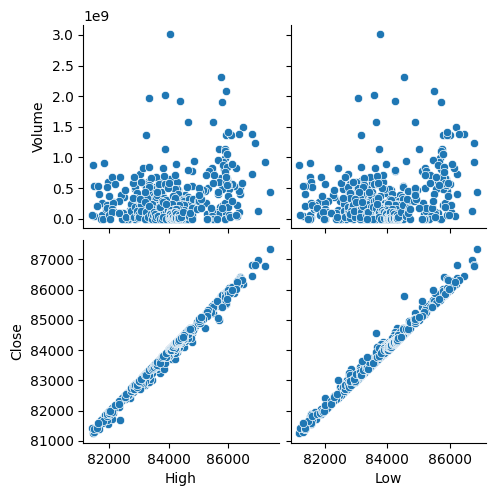

In [ ]:
#@title Code - View pairplot
sns.pairplot(training_df, x_vars=["High", "Low", ], y_vars=["Volume", "Close"])

# Part 3 - Train Model


---



## Define functions to view model information

To help visualize the results of each training run you will generate two plots at the end of each experiment:

* a scatter plot of the features vs. the label with a line showing the output of the trained model
* a loss curve

For this exercise, the plotting functions are provided for you. Unless you are interested, it is not important for you to understand how these plotting functions work.

**Instructions**
1. Run the **Define plotting functions** code cell.

In [ ]:
#@title Define plotting functions

def make_plots(df, feature_names, label_name, model_output, sample_size=200):

  random_sample = df.sample(n=sample_size).copy()
  random_sample.reset_index()
  weights, bias, epochs, rmse = model_output

  is_2d_plot = len(feature_names) == 1
  model_plot_type = "scatter" if is_2d_plot else "surface"
  fig = make_subplots(rows=1, cols=2,
                      subplot_titles=("Loss Curve", "Model Plot"),
                      specs=[[{"type": "scatter"}, {"type": model_plot_type}]])

  plot_data(random_sample, feature_names, label_name, fig)
  plot_model(random_sample, feature_names, weights, bias, fig)
  plot_loss_curve(epochs, rmse, fig)

  fig.show()
  return

def plot_loss_curve(epochs, rmse, fig):
  curve = px.line(x=epochs, y=rmse)
  curve.update_traces(line_color='#ff0000', line_width=3)

  fig.append_trace(curve.data[0], row=1, col=1)
  fig.update_xaxes(title_text="Epoch", row=1, col=1)
  fig.update_yaxes(title_text="Root Mean Squared Error", row=1, col=1, range=[rmse.min()*0.8, rmse.max()])

  return

def plot_data(df, features, label, fig):
  if len(features) == 1:
    scatter = px.scatter(df, x=features[0], y=label)
  else:
    scatter = px.scatter_3d(df, x=features[0], y=features[1], z=label)

  fig.append_trace(scatter.data[0], row=1, col=2)
  if len(features) == 1:
    fig.update_xaxes(title_text=features[0], row=1, col=2)
    fig.update_yaxes(title_text=label, row=1, col=2)
  else:
    fig.update_layout(scene1=dict(xaxis_title=features[0], yaxis_title=features[1], zaxis_title=label))

  return

def plot_model(df, features, weights, bias, fig):
  df['FARE_PREDICTED'] = bias[0]

  for index, feature in enumerate(features):
    df['FARE_PREDICTED'] = df['FARE_PREDICTED'] + weights[index][0] * df[feature]

  if len(features) == 1:
    model = px.line(df, x=features[0], y='FARE_PREDICTED')
    model.update_traces(line_color='#ff0000', line_width=3)
  else:
    z_name, y_name = "FARE_PREDICTED", features[1]
    z = [df[z_name].min(), (df[z_name].max() - df[z_name].min()) / 2, df[z_name].max()]
    y = [df[y_name].min(), (df[y_name].max() - df[y_name].min()) / 2, df[y_name].max()]
    x = []
    for i in range(len(y)):
      x.append((z[i] - weights[1][0] * y[i] - bias[0]) / weights[0][0])

    plane=pd.DataFrame({'x':x, 'y':y, 'z':[z] * 3})

    light_yellow = [[0, '#89CFF0'], [1, '#FFDB58']]
    model = go.Figure(data=go.Surface(x=plane['x'], y=plane['y'], z=plane['z'],
                                      colorscale=light_yellow))

  fig.add_trace(model.data[0], row=1, col=2)

  return

def model_info(feature_names, label_name, model_output):
  weights = model_output[0]
  bias = model_output[1]

  nl = "\n"
  header = "-" * 80
  banner = header + nl + "|" + "MODEL INFO".center(78) + "|" + nl + header

  info = ""
  equation = label_name + " = "

  for index, feature in enumerate(feature_names):
    info = info + "Weight for feature[{}]: {:.3f}\n".format(feature, weights[index][0])
    equation = equation + "{:.3f} * {} + ".format(weights[index][0], feature)

  info = info + "Bias: {:.3f}\n".format(bias[0])
  equation = equation + "{:.3f}\n".format(bias[0])

  return banner + nl + info + nl + equation

print("SUCCESS: defining plotting functions complete.")

SUCCESS: defining plotting functions complete.


## Define functions to build and train a model

The code you need to build and train your model is in the **Define ML functions** code cell. If you would like to explore this code, expand the code cell and take a look.

**Instructions**
1. Run the **Define ML functions** code cell.

In [ ]:
#@title Code - Define ML functions

def build_model(my_learning_rate, num_features):
  """Create and compile a simple linear regression model."""
  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  inputs = keras.Input(shape=(num_features,))
  outputs = keras.layers.Dense(units=1)(inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # Compile the model topography into code that Keras can efficiently
  # execute. Configure training to minimize the model's mean squared error.
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=my_learning_rate),
                loss="mean_squared_error",
                metrics=[keras.metrics.RootMeanSquaredError()])

  return model


def train_model(model, df, features, label, epochs, batch_size):
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs.
  # input_x = df.iloc[:,1:3].values
  # df[feature]
  history = model.fit(x=features,
                      y=label,
                      batch_size=batch_size,
                      epochs=epochs)

  # Gather the trained model's weight and bias.
  trained_weight = model.get_weights()[0]
  trained_bias = model.get_weights()[1]

  # The list of epochs is stored separately from the rest of history.
  epochs = history.epoch

  # Isolate the error for each epoch.
  hist = pd.DataFrame(history.history)

  # To track the progression of training, we're going to take a snapshot
  # of the model's root mean squared error at each epoch.
  rmse = hist["root_mean_squared_error"]

  return trained_weight, trained_bias, epochs, rmse


def run_experiment(df, feature_names, label_name, learning_rate, epochs, batch_size):

  print('INFO: starting training experiment with features={} and label={}\n'.format(feature_names, label_name))

  num_features = len(feature_names)

  features = df.loc[:, feature_names].values
  label = df[label_name].values

  model = build_model(learning_rate, num_features)
  model_output = train_model(model, df, features, label, epochs, batch_size)

  print('\nSUCCESS: training experiment complete\n')
  print('{}'.format(model_info(feature_names, label_name, model_output)))
  make_plots(df, feature_names, label_name, model_output)

  return model

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.


## Train a model with one feature

In this step you will train a model to predict the cost of the fare using a **single feature**. Earlier, you saw that `TRIP_MILES` (distance) correlates most strongly with the ``FARE``, so let's start with `TRIP_MILES` as the feature for your first training run.

**Instructions**

1. Run the **Experiment 1** code cell to build your model with one feature.
1. Review the output from the training run
1. **Check your understanding** by answering these questions:
  * How many epochs did it take to converge on the final model?
  * How well does the model fit the sample data?

During training, you should see the root mean square error (RMSE) in the output. The units for RMSE are the same as the units for the label (dollars). In other words, you can use the RMSE to determine how far off, on average, the predicted fares are in dollars from the observed values.

In [ ]:
# Required Imports
import numpy as np
import pandas as pd
import yfinance as yf
import keras
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Fetch Bitcoin data
btc = yf.Ticker("BTC-USD")
training_df = btc.history(period="7d", interval="15m")[['High', 'Low', 'Close', 'Volume']]
# training_df['Datetime'] = training_df.index

# Scale Features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

features = ['High']
label = 'Volume'

training_df[features] = scaler_X.fit_transform(training_df[features])
training_df[[label]] = scaler_y.fit_transform(training_df[[label]])

# Define Model Building Function
def build_model(my_learning_rate, num_features):
    inputs = keras.Input(shape=(num_features,))
    outputs = keras.layers.Dense(units=1)(inputs)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=my_learning_rate),
                  loss="mean_squared_error",
                  metrics=[keras.metrics.RootMeanSquaredError()])
    return model

# Training Function
def train_model(model, x_train, y_train, epochs, batch_size):
    history = model.fit(x=x_train, y=y_train, batch_size=batch_size, epochs=epochs, verbose=0)

    trained_weight = model.get_weights()[0]
    trained_bias = model.get_weights()[1]

    rmse = pd.DataFrame(history.history)["root_mean_squared_error"]

    return trained_weight, trained_bias, history.epoch, rmse

# Define Plotting Functions
def plot_data(df, feature_names, label_name, fig):
    fig.add_trace(go.Scatter(
        x=df[feature_names[0]],
        y=df[label_name],
        mode='markers',
        name="Data"
    ), row=1, col=2)

def plot_model(df, feature_names, weights, bias, fig):
    x = np.linspace(df[feature_names[0]].min(), df[feature_names[0]].max(), 100)
    y = weights[0] * x + bias

    fig.add_trace(go.Scatter(
        x=x,
        y=y.flatten(),
        mode='lines',
        name="Model"
    ), row=1, col=2)

def plot_loss_curve(epochs, rmse, fig):
    fig.add_trace(go.Scatter(
        x=epochs,
        y=rmse,
        mode="lines+markers",
        name="Loss Curve"
    ), row=1, col=1)

# Function to Generate Plots
def make_plots(df, feature_names, label_name, model_output, sample_size=200):
    random_sample = df.sample(n=sample_size).copy().reset_index(drop=True)

    weights, bias, epochs, rmse = model_output
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Loss Curve", "Model Plot"),
                        specs=[[{"type": "scatter"}, {"type": "scatter"}]])

    plot_data(random_sample, feature_names, label_name, fig)
    plot_model(random_sample, feature_names, weights, bias, fig)
    plot_loss_curve(epochs, rmse, fig)

    fig.show()

# Run Experiment Function
def run_experiment(df, feature_names, label_name, learning_rate, epochs, batch_size):
    print(f'INFO: Starting training with features={feature_names} and label={label_name}')

    num_features = len(feature_names)

    x_train = df.loc[:, feature_names].values
    y_train = df[label_name].values.reshape(-1, 1)

    model = build_model(learning_rate, num_features)
    model_output = train_model(model, x_train, y_train, epochs, batch_size)

    print(f'SUCCESS: Training complete')

    make_plots(df, feature_names, label_name, model_output)
    return model

# Hyperparameters
learning_rate = 0.0008
epochs = 110
batch_size = 150

# Run Experiment
model_1 = run_experiment(training_df, features, label, learning_rate, epochs, batch_size)


INFO: Starting training with features=['High'] and label=Volume
SUCCESS: Training complete


In [ ]:
#@title Double-click to view answers for training model with one feature

# How many epochs did it take to converge on the final model?
# -----------------------------------------------------------------------------
answer = """
Use the loss curve to see where the loss begins to level off during training.

With this set of hyperparameters:

  learning_rate = 0.001
  epochs = 20
  batch_size = 50

it takes about 5 epochs for the training run to converge to the final model.
"""
print(answer)

# How well does the model fit the sample data?
# -----------------------------------------------------------------------------
answer = '''
It appears from the model plot that the model fits the sample data fairly well.
'''
print(answer)


Use the loss curve to see where the loss begins to level off during training.

With this set of hyperparameters:

  learning_rate = 0.001
  epochs = 20
  batch_size = 50

it takes about 5 epochs for the training run to converge to the final model.


It appears from the model plot that the model fits the sample data fairly well.



## Experiment with hyperparameters

It is common with machine learning to run multiple experiments to find the best set of hyperparmeters to train your model. In this step, try varying the hyperparameters one by one with this set of experiments:

* *Experiment 1:* **Increase** the learning rate to **``1``** (batch size at ``50``).
* *Experiment 2:* **Decrease** the learning rate to **``0.0001``** (batch size at ``50``).
* *Experiment 3:* **Increase** the batch size to **``500``** (learning rate at ``0.001``).

**Instructions**
1. Update the hyperparameter values in the **Experiment 2** code cell according to the experiment.
2. Run the **Experiment 2** code cell.
3. After the training run, examine the output and note any differences you see in the loss curve or model output.
4. Repeat steps 1 - 3 for each hyperparameter experiment.
5. **Check your understanding** by answering these questions:
  * How did raising the learning rate impact your ability to train the model?
  * How did lowering the learning rate impact your ability to train the model?
  * Did changing the batch size effect your training results?


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# ✅ Standardization instead of MinMax
scaler_X = StandardScaler()
scaler_y = StandardScaler()

training_df[features] = scaler_X.fit_transform(training_df[features])
training_df[[label]] = scaler_y.fit_transform(training_df[[label]])

# ✅ Adjusted Model with Dropout
def run_experiment(df, features, label, learning_rate=0.0001, epochs=30, batch_size=64):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(len(features),)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mean_absolute_error',
        metrics=['root_mean_squared_error']
    )

    # ✅ Train Model
    history = model.fit(
        df[features], df[[label]],
        epochs=epochs, batch_size=batch_size, verbose=1
    )

    return model

# ✅ Run Experiment
model_1 = run_experiment(training_df, features, label)
# Hyperparameters
learning_rate = 0.0001
epochs = 110
batch_size = 150

# Run Experiment
model_1 = run_experiment(training_df, features, label, learning_rate, epochs, batch_size)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.0694 - root_mean_squared_error: 1.5117
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0563 - root_mean_squared_error: 1.4810 
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9597 - root_mean_squared_error: 1.3956 
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9500 - root_mean_squared_error: 1.3133 
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0282 - root_mean_squared_error: 1.4544 
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0132 - root_mean_squared_error: 1.5428 
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8867 - root_mean_squared_error: 1.3345 
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0200 - root_mean_squared_error: 1.4724 
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9232 - root_mean_squared_error: 1.3118 
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9145 - root_mean_squared_error: 1.2922 


In [ ]:
#@title Double-click to view answers for hyperparameter experiments

# How did raising the learning rate impact your ability to train the model?
# -----------------------------------------------------------------------------
answer = """
When the learning rate is too high, the loss curve bounces around and does not
appear to be moving towards convergence with each iteration. Also, notice that
the predicted model does not fit the data very well. With a learning rate that
is too high, it is unlikely that you will be able to train a model with good
results.
"""
print(answer)

# How did lowering the learning rate impact your ability to train the model?
# -----------------------------------------------------------------------------
answer = '''
When the learning rate is too small, it may take longer for the loss curve to
converge. With a small learning rate the loss curve decreases slowly, but does
not show a dramatic drop or leveling off. With a small learning rate you could
increase the number of epochs so that your model will eventually converge, but
it will take longer.
'''
print(answer)

# Did changing the batch size effect your training results?
# -----------------------------------------------------------------------------
answer = '''
Increasing the batch size makes each epoch run faster, but as with the smaller
learning rate, the model does not converge with just 20 epochs. If you have
time, try increasing the number of epochs and eventually you should see the
model converge.
'''
print(answer)


When the learning rate is too high, the loss curve bounces around and does not
appear to be moving towards convergence with each iteration. Also, notice that
the predicted model does not fit the data very well. With a learning rate that
is too high, it is unlikely that you will be able to train a model with good
results.


When the learning rate is too small, it may take longer for the loss curve to
converge. With a small learning rate the loss curve decreases slowly, but does
not show a dramatic drop or leveling off. With a small learning rate you could
increase the number of epochs so that your model will eventually converge, but
it will take longer.


Increasing the batch size makes each epoch run faster, but as with the smaller
learning rate, the model does not converge with just 20 epochs. If you have
time, try increasing the number of epochs and eventually you should see the
model converge.



## Train a model with two features

The model you trained with the feature ``TOTAL_MILES`` demonstrates fairly strong predictive power, but is it possible to do better? In this step, try training the model with two features, ``TRIP_MILES`` and ``TRIP_MINUTES``, to see if you can improve the model. You may recall that the original dataset does not include a feature ``TRIP_MINUTES``, but this feature can be easily derived from ``TRIP_SECONDS`` as shown in the code below.*

**Instructions**
1. Review the code in **Experiment 3** code cell.
1. Run the **Experiment 3** code cell.
1. Review the output from the training run and answer these questions:
  * Does the model with two features produce better results than one using a single feature?
  * Does it make a difference if you use ``TRIP_SECONDS`` instead of ``TRIP_MINUTES``?
  * How well do you think the model comes to the ground truth fare calculation for Chicago Taxi Trips?


Notice that the scatter plot of the features vs. the label is a three dimensional (3-D) plot. This representation allows you to visualize both features and the label all together. The two features (TRIP_MILES and TRIP_MINUTES) are on the x and y axis, and the label (FARE) is on the z axis. The plot shows individual examples in the dataset as circles, and the model as a surface (plane). With this 3-D model, if the trained model is good you would expect most of the examples to land on the plane surface. The 3-D plot is interactive so you can explore the data further by clicking or dragging the plot.


In [ ]:
# ✅ Standard Scaling for Better Training
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
scaler_X = StandardScaler()
scaler_y = StandardScaler()

training_df[features] = scaler_X.fit_transform(training_df[features])
training_df[[label]] = scaler_y.fit_transform(training_df[[label]])

# ✅ Improved Model
def run_experiment(df, features, label, learning_rate=0.0001, epochs=30, batch_size=64):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(len(features),)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)  # Predict a single value
    ])

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mean_squared_error',
                  metrics=['root_mean_squared_error'])

    # ✅ Train Model
    history = model.fit(df[features].values, df[label].values,
                        epochs=epochs, batch_size=batch_size, verbose=1)

    return model

# ✅ Run Experiment with Fixes
model_2 = run_experiment(training_df, features, label)
# Hyperparameters
learning_rate = 0.0008
epochs = 110
batch_size = 150

# Run Experiment
model_1 = run_experiment(training_df, features, label, learning_rate, epochs, batch_size)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3.4891 - root_mean_squared_error: 1.8674
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.8128 - root_mean_squared_error: 1.6769
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.3339 - root_mean_squared_error: 1.5276
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.1712 - root_mean_squared_error: 1.4715
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1124 - root_mean_squared_error: 1.4507  
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6714 - root_mean_squared_error: 1.2920  
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3838 - root_mean_squared_error: 1.1757 
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6630 - root_mean_squared_error: 1.2870 
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5565 - root_mean_squared_error: 1.2471 
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2816 - root_mean_squared_error: 1.1285 
Epoch 11

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.8199 - root_mean_squared_error: 1.3484
Epoch 2/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3788 - root_mean_squared_error: 1.1731 
Epoch 3/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.4519 - root_mean_squared_error: 1.2040  
Epoch 4/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1881 - root_mean_squared_error: 1.0891  
Epoch 5/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0544 - root_mean_squared_error: 1.0256  
Epoch 6/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0778 - root_mean_squared_error: 1.0378
Epoch 7/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8600 - root_mean_squared_error: 0.9207 
Epoch 8/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9483 - root_mean_squared_error: 0.9711  
Epoch 9/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9652 - root_mean_squared_error: 0.9812  
Epoch 10/110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9543 - root_mean_squared_error: 0.9763 
Epoch 11/110
5/5 

# Part 4 - Validate Model


---



## Use the model to make predictions

Now that you have a trained model, you can use the model to make predictions. In practice, you should make predictions on examples that are not used during training. However, for this exercise, you'll just work with a subset of the same training dataset. In another Colab exercise you will explore ways to make predictions on examples not used in training.

**Instructions**

1. Run the **Define functions to make predictions** code cell.
1. Run the **Make predictions** code cell.
1. Review the predictions in the output.
1. **Check your understanding** by answering these questions:
  * How close is the predicted value to the label value? In other words, does your model accurately predict the fare for a taxi ride?

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LSTM
from tensorflow.keras.optimizers import Adam

# ... (Previous code for data fetching, scaling, and model training)

# Function to make predictions
def predict_price(model, df, features, label, scaler_X, scaler_y, batch_size=50):
    batch = df.sample(n=batch_size, replace=True).copy()
    batch.reset_index(drop=True, inplace=True)

    # Predict the scaled price change using the trained model
    predicted_scaled_change = model.predict_on_batch(
        batch[features].values.reshape(batch[features].shape[0], batch[features].shape[1], 1)
    )

    # Inverse transform to get the actual price change
    predicted_change = scaler_y.inverse_transform(predicted_scaled_change)

    # Apply the price change to the original 'High' price, but use the original 'High' values
    original_high_values = scaler_X.inverse_transform(batch[features].values)
    batch['PREDICTED_PRICE'] = original_high_values.flatten() + (original_high_values.flatten() * predicted_change.flatten())

    # Get the original 'Close' prices for comparison
    # observed_actual = scaler_y.inverse_transform(batch[[label]].values)
    observed_prices = scaler_X.inverse_transform(batch[features].values).flatten()  # Use High as observed price
    l1_loss = np.abs(batch['PREDICTED_PRICE'] - observed_prices)
    output_df = pd.DataFrame({
        "PREDICTED_PRICE": batch['PREDICTED_PRICE'],
        "OBSERVED_PRICE": observed_prices,  # Assign observed prices here
        "L1_LOSS": l1_loss  # Assign L1 Loss here
    })
    return output_df

output = predict_price(model_2, scaled_df, features, label, scaler_X, scaler_y)

def show_predictions(df):
    print(df.to_string(index=False))

show_predictions(output)

 PREDICTED_PRICE  OBSERVED_PRICE  L1_LOSS
    83361.098180    83354.203125 6.895055
    84070.649376    84065.640625 5.008751
    83966.010785    83960.375000 5.635785
    82670.346808    82662.328125 8.018683
    84710.981143    84708.281250 2.699893
    84270.722450    84266.828125 3.894325
    84295.176142    84291.367188 3.808955
    85464.628038    85463.679688 0.948351
    83749.133497    83742.937500 6.195997
    84246.227521    84242.242188 3.985334
    83779.324130    83773.187500 6.136630
    84780.836502    84778.296875 2.539627
    84203.687766    84199.523438 4.164329
    85939.257882    85939.468750 0.210868
    83249.584776    83242.500000 7.084776
    83474.443979    83467.750000 6.693979
    83865.630707    83859.671875 5.958832
    86798.081724    86799.921875 1.840151
    84045.291439    84040.117188 5.174251
    84288.012491    84284.179688 3.832804
    83304.967677    83297.976562 6.991115
    84000.065249    83994.601562 5.463686
    82081.867744    82072.976562 8

In [ ]:
!pip install yfinance tensorflow scikit-learn

import numpy as np
import pandas as pd
import tensorflow as tf
import yfinance as yf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import datetime
import pytz

# Enable TensorFlow Debug Mode (optional)
# tf.data.experimental.enable_debug_mode()

# 🔹 Fetch Bitcoin Data from Yahoo Finance
def fetch_btc_data():
    ticker = 'BTC-USD'
    data = yf.download(ticker, period='7d', interval='15m')
    data = data[['Close']]  # Only using 'Close' price for this example
    data.rename(columns={'Close': 'price'}, inplace=True)
    return data

# 🔹 Define Features and Target
features = ['price']
label = 'price'

# Fetch initial training data
training_df = fetch_btc_data()

# 🔹 Scale Features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(training_df[features])
y_scaled = scaler_y.fit_transform(training_df[[label]])

# 🔹 Define Neural Network Model
model = Sequential([
    Input(shape=(X_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Output layer for regression
])

# 🔹 Compile Model
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss=Huber())  # Huber loss for robustness

# 🔹 Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 🔹 Train Model
model.fit(X_scaled, y_scaled, epochs=50, batch_size=32, verbose=1, validation_split=0.2, callbacks=[early_stop])

# 🔹 Generate Predictions and Validate in Real-time
current_price = training_df['price'].iloc[-1]
predictions = []
now = datetime.datetime.now(pytz.utc)

for i in range(40):  # Predict for the next 10 hours (40 * 15 minutes)
    input_data = np.array([[current_price]])
    input_data_scaled = scaler_X.transform(input_data)
    predicted_scaled = model.predict(input_data_scaled)
    predicted_price = scaler_y.inverse_transform(predicted_scaled)[0, 0]
    predictions.append([predicted_price, current_price, now + datetime.timedelta(minutes=15 * i)])
    current_price = predicted_price  # Update current_price for next prediction

prediction_df = pd.DataFrame(predictions, columns=['PREDICTED_PRICE', 'CURRENT_PRICE', 'TIMESTAMP'])
prediction_df.set_index('TIMESTAMP', inplace=True)

# 🔹 Fetch Actual BTC Prices for Elapsed Predictions
actual_data = fetch_btc_data()  # Fetch updated data for comparison

# 🔹 Merge Data for Accuracy Calculation
actual_data = actual_data[['price']]
merged_data = pd.merge(prediction_df, actual_data, left_index=True, right_index=True, how='inner')
merged_data.rename(columns={'price': 'ACTUAL_PRICE'}, inplace=True)

# 🔹 Calculate Accuracy Metrics
merged_data['ERROR'] = merged_data['PREDICTED_PRICE'] - merged_data['ACTUAL_PRICE']
merged_data['ABSOLUTE_ERROR'] = np.abs(merged_data['ERROR'])
merged_data['PERCENTAGE_ERROR'] = (merged_data['ABSOLUTE_ERROR'] / merged_data['ACTUAL_PRICE']) * 100
merged_data['MATCH'] = merged_data['ABSOLUTE_ERROR'].apply(lambda x: '✔️' if x < 10 else '❌')

mae = merged_data['ABSOLUTE_ERROR'].mean()
mape = merged_data['PERCENTAGE_ERROR'].mean()
rmse = np.sqrt((merged_data['ERROR'] ** 2).mean())

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# 🔹 Print Merged Data for Analysis
print(merged_data)

[*********************100%***********************]  1 of 1 completed

Epoch 1/50


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.3827 - val_loss: 0.0617
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1741 - val_loss: 0.0143
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0465 - val_loss: 0.0101
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0112 - val_loss: 0.0097
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0103 - val_loss: 0.0026
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0104 - val_loss: 0.0017
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 - val_loss: 6.6726e-04
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0048 - val_loss: 1.2151e-04
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0043 - val_loss: 2.6136e-04
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - val_loss: 6.6347e-05
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045 - val_loss: 2.4012e-04
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.005

ValueError: Found array with dim 3. StandardScaler expected <= 2.

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Define the ticker symbol for Bitcoin
ticker = 'BTC-USD'

# Calculate the time range
end_time = datetime.now()
start_time = end_time - timedelta(hours=5)

# Fetch historical data with 15-minute intervals
btc_data = yf.download(ticker, start=start_time, end=end_time, interval='15m')

# Reset index to access the 'Datetime' column
btc_data.reset_index(inplace=True)

# Print fetched data
print("Fetched Yahoo Finance Bitcoin Price Data:\n")
print(btc_data)

# Sample predicted prices (replace with your actual predictions)
predicted_prices = [83361.098180, 84070.649376, 83966.010785, 82670.346808, 84710.981143,
                    84270.722450, 84295.176142, 85464.628038, 83749.133497, 84246.227521,
                    83779.324130, 84780.836502, 84203.687766, 85939.257882, 83249.584776,
                    83474.443979, 83865.630707, 86798.081724, 84045.291439, 84288.012491]

# Ensure the number of predictions matches the number of observed prices
num_observations = len(btc_data)
num_predictions = len(predicted_prices)

if num_predictions > num_observations:
    print(f"Warning: More predictions ({num_predictions}) than observed prices ({num_observations}). Adjusting.")
    predicted_prices = predicted_prices[:num_observations]  # Trim extra predictions

elif num_predictions < num_observations:
    print(f"Warning: More observed prices ({num_observations}) than predictions ({num_predictions}). Adjusting.")
    btc_data = btc_data.iloc[:num_predictions]  # Trim extra observations

# Compare predicted and observed prices
comparison_results = []
# Iterate using the index to ensure alignment
for index in btc_data.index:
    predicted = predicted_prices[index]  # Assuming predicted_prices are aligned with DataFrame index
    observed = btc_data.loc[index, 'Close']  # Access using .loc for row label and column name
    l1_loss = abs(predicted - observed)
    match = abs(predicted - observed) < 1e-5  # Considering floating-point precision
    comparison_results.append([predicted, observed, l1_loss, match])

# Create a DataFrame for better visualization
comparison_df = pd.DataFrame(comparison_results, columns=['PREDICTED_PRICE', 'OBSERVED_PRICE', 'L1_LOSS', 'MATCH'])

# Display the comparison
print("\nComparison of Predicted vs Observed Bitcoin Prices:\n")
print(comparison_df)

[*********************100%***********************]  1 of 1 completed

Fetched Yahoo Finance Bitcoin Price Data:

Price                   Datetime         Close          High           Low  \
Ticker                                 BTC-USD       BTC-USD       BTC-USD   
0      2025-03-23 16:15:00+00:00  85295.320312  85297.875000  85258.687500   
1      2025-03-23 16:30:00+00:00  85040.015625  85280.406250  84983.656250   
2      2025-03-23 16:45:00+00:00  85271.140625  85346.195312  85095.289062   
3      2025-03-23 17:00:00+00:00  85316.828125  85370.476562  85280.945312   
4      2025-03-23 17:15:00+00:00  85259.437500  85379.031250  85259.437500   
5      2025-03-23 17:30:00+00:00  84995.476562  85249.453125  84995.476562   
6      2025-03-23 17:45:00+00:00  84984.203125  85095.757812  84962.593750   
7      2025-03-23 18:00:00+00:00  84902.625000  84996.359375  84902.625000   
8      2025-03-23 18:15:00+00:00  84856.265625  84977.656250  84840.226562   
9      2025-03-23 18:30:00+00:00  84955.039062  84955.039062  84838.828125   
10     2025-03-23 18:

In [ ]:
import requests

# BitMEX API endpoint for instrument data
url = 'https://www.bitmex.com/api/v1/instrument/active'

# Making the API request
response = requests.get(url)

# Checking if the request was successful
if response.status_code == 200:
    data = response.json()
    # Filtering for Bitcoin (XBT) instruments
    btc_instruments = [instrument for instrument in data if 'XBT' in instrument['symbol']]
    for instrument in btc_instruments:
        symbol = instrument.get('symbol')
        open_interest = instrument.get('openInterest')
        print(f"Symbol: {symbol}, Open Interest: {open_interest}")
else:
    print(f"Error: {response.status_code}")


Symbol: AIXBTUSDT, Open Interest: 828
Symbol: XBTETH, Open Interest: 134577
Symbol: XBTUSD, Open Interest: 247708400
Symbol: XBTUSDT, Open Interest: 151537600
Symbol: XBTEUR, Open Interest: 1189000
Symbol: XBTH25, Open Interest: 22500500
Symbol: XBTUSDTH25, Open Interest: 104000
Symbol: XBTJ25, Open Interest: 149900
Symbol: XBTM25, Open Interest: 40775800
Symbol: XBTUSDTM25, Open Interest: 0
Symbol: XBTU25, Open Interest: 14416900
Symbol: XBTZ25, Open Interest: 14181000
Symbol: XBT_USDT, Open Interest: 0
Symbol: ETH_XBT, Open Interest: 0
Symbol: XBTK25, Open Interest: 0
Symbol: XBTN25, Open Interest: 0
Symbol: XBTQ25, Open Interest: 0
Symbol: XBTUSDTU25, Open Interest: 0
Symbol: XBTV25, Open Interest: 0
Symbol: XBTX25, Open Interest: 0
Symbol: XBTUSDTZ25, Open Interest: 0
Symbol: SOL_XBT, Open Interest: 0
Symbol: USDC_XBT, Open Interest: 0


In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta

# ✅ Correct API Endpoint
api_url = "https://api.coinalyze.net/v1/open-interest-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 2 hours)
params = {
    "symbols": "BTCUSDT_PERP.A",  # Bitcoin Perpetual Contract
    "interval": "15min",  # 15-minute intervals
    "from": int((datetime.utcnow() - timedelta(hours=2)).timestamp()),  # 2 hours ago
    "to": int(datetime.utcnow().timestamp()),  # Current time
    "convert_to_usd": "false"
}

# ✅ Send GET request to API with headers
headers = {"api_key": api_key}
response = requests.get(api_url, headers=headers, params=params)

# ✅ Print API response status
print("Status Code:", response.status_code)

# ✅ Process API response
try:
    response_data = response.json()
    print("\n🔹 Full API Response:")
    print(json.dumps(response_data, indent=2))  # Pretty-print response

    # ✅ Check if response contains 'history'
    if response_data and isinstance(response_data, list) and "history" in response_data[0]:
        history_data = response_data[0]["history"]

        # ✅ Convert response to DataFrame
        df = pd.DataFrame(history_data)

        # ✅ Rename columns based on API response structure
        df.rename(columns={"t": "Timestamp", "o": "Open Interest"}, inplace=True)

        # ✅ Convert timestamps to datetime format
        df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")

        # ✅ Display DataFrame
        print("\n🔹 DataFrame Preview:")
        print(df.head())

        # ✅ Save to CSV
        df.to_csv("bitcoin_open_interest_2hours.csv", index=False)
        print("\n✅ Data saved to 'bitcoin_open_interest_2hours.csv'")

    else:
        print("\n❌ API response does not contain expected data structure.")

except json.JSONDecodeError:
    print("\n❌ Failed to decode JSON response:", response.text)


Status Code: 200

🔹 Full API Response:
[
  {
    "symbol": "BTCUSDT_PERP.A",
    "history": [
      {
        "t": 1742760900,
        "o": 71914.405,
        "h": 71928.478,
        "l": 71787.284,
        "c": 71787.284
      },
      {
        "t": 1742761800,
        "o": 71787.776,
        "h": 71788.236,
        "l": 71514.199,
        "c": 71527.009
      },
      {
        "t": 1742762700,
        "o": 71527.147,
        "h": 71527.147,
        "l": 71483.862,
        "c": 71483.862
      },
      {
        "t": 1742763600,
        "o": 71480.83,
        "h": 71495.45,
        "l": 71452.046,
        "c": 71470.188
      },
      {
        "t": 1742764500,
        "o": 71470.332,
        "h": 71504.683,
        "l": 71459.145,
        "c": 71499.445
      },
      {
        "t": 1742765400,
        "o": 71498.242,
        "h": 71498.242,
        "l": 71446.983,
        "c": 71446.984
      },
      {
        "t": 1742766300,
        "o": 71446.876,
        "h": 71455.191,
     

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta

# API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest"
ohlc_url = "https://api.coinalyze.net/v1/ohlcv"  # Check if this exists

# API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# Symbol
symbol = "BTCUSDT_PERP.A"  # Try "BTCUSDT" if this fails

# Parameters for Open Interest
open_interest_params = {
    "symbols": symbol,
    "convert_to_usd": "false"
}

# Parameters for OHLC
ohlc_params = {
    "symbols": symbol,
    "interval": "5min",  # Using 5-minute OHLC
    "from": int((datetime.utcnow() - timedelta(minutes=30)).timestamp()),  # Last 30 mins
    "to": int(datetime.utcnow().timestamp())  # Current time
}

# Headers
headers = {"api_key": api_key}

# Fetch Open Interest
oi_response = requests.get(open_interest_url, headers=headers, params=open_interest_params)

# Fetch OHLC Data
ohlc_response = requests.get(ohlc_url, headers=headers, params=ohlc_params)

# Process Open Interest Response
if oi_response.status_code == 200:
    oi_data = oi_response.json()
    if oi_data and isinstance(oi_data, list):
        oi_df = pd.DataFrame(oi_data)
        oi_df["Timestamp UTC"] = pd.to_datetime(oi_df["update"], unit="ms")
        oi_df["Timestamp IST"] = oi_df["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        oi_df = oi_df[["Timestamp UTC", "Timestamp IST", "value"]]
        oi_df.columns = ["Timestamp UTC", "Timestamp IST", "Open Interest"]
    else:
        print("\n❌ Open Interest API response does not contain expected data.")
        oi_df = None
else:
    print("\n❌ Error fetching Open Interest:", oi_response.status_code, oi_response.text)
    oi_df = None

# Process OHLC Response
if ohlc_response.status_code == 200:
    try:
        ohlc_data = ohlc_response.json()
        if ohlc_data and isinstance(ohlc_data, list) and "history" in ohlc_data[0]:
            ohlc_df = pd.DataFrame(ohlc_data[0]["history"])
            ohlc_df["Timestamp UTC"] = pd.to_datetime(ohlc_df["t"], unit="s")
            ohlc_df["Timestamp IST"] = ohlc_df["Timestamp UTC"] + timedelta(hours=5, minutes=30)
            ohlc_df = ohlc_df[["Timestamp UTC", "Timestamp IST", "o", "h", "l", "c"]]
            ohlc_df.columns = ["Timestamp UTC", "Timestamp IST", "Open", "High", "Low", "Close"]
        else:
            print("\n❌ OHLC API response does not contain expected data.")
            ohlc_df = None
    except Exception as e:
        print("\n❌ Error processing OHLC data:", str(e))
        ohlc_df = None
else:
    print("\n❌ Error fetching OHLC:", ohlc_response.status_code, ohlc_response.text)
    ohlc_df = None

# Print Results
if oi_df is not None:
    print("\n🔹 Latest Open Interest Data (Converted to IST):")
    print(oi_df)

if ohlc_df is not None:
    print("\n🔹 Latest OHLC Data (Converted to IST):")
    print(ohlc_df)



❌ Error fetching OHLC: 404 {"message":"not found"}

🔹 Latest Open Interest Data (Converted to IST):
            Timestamp UTC           Timestamp IST  Open Interest
0 2025-03-23 22:21:17.273 2025-03-24 03:51:17.273      71510.427


In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta

# ✅ Correct API Endpoint
api_url = "https://api.coinalyze.net/v1/open-interest-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 2 hours)
params = {
    "symbols": "BTCUSDT_PERP.A",  # Bitcoin Perpetual Contract
    "interval": "15min",  # 15-minute intervals
    "from": int((datetime.utcnow() - timedelta(hours=2)).timestamp()),  # 2 hours ago
    "to": int(datetime.utcnow().timestamp()),  # Current time
    "convert_to_usd": "true"  # ✅ Changed from "false" to "true"
}

# ✅ Send GET request to API with headers
headers = {"api_key": api_key}
response = requests.get(api_url, headers=headers, params=params)

# ✅ Print API response status
print("Status Code:", response.status_code)

# ✅ Process API response
try:
    response_data = response.json()
    print("\n🔹 Full API Response:")
    print(json.dumps(response_data, indent=2))  # Pretty-print response

    # ✅ Check if response contains 'history'
    if response_data and isinstance(response_data, list) and "history" in response_data[0]:
        history_data = response_data[0]["history"]

        # ✅ Convert response to DataFrame
        df = pd.DataFrame(history_data)

        # ✅ Rename columns based on API response structure
        df.rename(columns={"t": "Timestamp", "o": "Open Interest"}, inplace=True)

        # ✅ Convert timestamps to datetime format
        df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")

        # ✅ Display DataFrame
        print("\n🔹 DataFrame Preview:")
        print(df.head())

        # ✅ Save to CSV
        df.to_csv("bitcoin_open_interest_2hours.csv", index=False)
        print("\n✅ Data saved to 'bitcoin_open_interest_2hours.csv'")

    else:
        print("\n❌ API response does not contain expected data structure.")

except json.JSONDecodeError:
    print("\n❌ Failed to decode JSON response:", response.text)


Status Code: 200

🔹 Full API Response:
[
  {
    "symbol": "BTCUSDT_PERP.A",
    "history": [
      {
        "t": 1742763600,
        "o": 6070223564.43,
        "h": 6071465109.45,
        "l": 6067779198.366,
        "c": 6069319835.148
      },
      {
        "t": 1742764500,
        "o": 6072605404.9776,
        "h": 6075524099.524401,
        "l": 6071654881.386001,
        "c": 6075079043.426001
      },
      {
        "t": 1742765400,
        "o": 6071280369.2542,
        "h": 6071280369.2542,
        "l": 6066927706.1433,
        "c": 6066927791.0584
      },
      {
        "t": 1742766300,
        "o": 6083279954.831601,
        "h": 6083987928.023101,
        "l": 6081535863.087201,
        "c": 6081801938.399701
      },
      {
        "t": 1742767200,
        "o": 6096898861.2804,
        "h": 6099286159.5174,
        "l": 6080448438.934801,
        "c": 6080448438.934801
      },
      {
        "t": 1742768100,
        "o": 6088458729.199,
        "h": 6112590745.582

In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 2 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=2)).timestamp())  # 2 hours ago
to_timestamp = int(datetime.utcnow().timestamp())  # Current time

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

# ✅ Send GET request for Open Interest
headers = {"api_key": api_key}
response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

if response_oi.status_code == 200:
    response_data_oi = response_oi.json()

    if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
        history_data_oi = response_data_oi[0]["history"]

        # ✅ Convert Open Interest data to DataFrame
        df_oi = pd.DataFrame(history_data_oi)
        df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)

        # ✅ Convert UTC timestamps to IST
        df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
        df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)  # Convert to IST

        # ✅ Debug: Check if IST timestamp is added correctly
        print("\n🔹 Open Interest Data Preview (with IST):")
        print(df_oi.head())

        # ✅ OHLCV Parameters
        params_ohlcv = {
            "symbols": "BTCUSDT_PERP.A",
            "interval": "15min",
            "from": from_timestamp,
            "to": to_timestamp
        }

        # ✅ Send GET request for OHLCV
        response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

        if response_ohlcv.status_code == 200:
            response_data_ohlcv = response_ohlcv.json()

            if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
                history_data_ohlcv = response_data_ohlcv[0]["history"]

                # ✅ Convert OHLCV data to DataFrame
                df_ohlcv = pd.DataFrame(history_data_ohlcv)
                df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)

                # ✅ Convert UTC timestamps to IST
                df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
                df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)  # Convert to IST

                # ✅ Debug: Check if IST timestamp is added correctly
                print("\n🔹 OHLCV Data Preview (with IST):")
                print(df_ohlcv.head())

                # ✅ Merge Open Interest and Bitcoin Price Data on **Timestamp UTC**
                df_final = pd.merge(df_oi, df_ohlcv, on="Timestamp UTC", how="inner")

                # ✅ Debug: Check final DataFrame columns before filtering
                print("\n🔹 Final Merged Data Columns:")
                print(df_final.columns)

                # ✅ Display Final DataFrame
                print("\n🔹 Merged Data (Open Interest + Bitcoin Price) with IST:")
                print(df_final[["Timestamp IST_x", "Open Interest", "OI High", "OI Low", "OI Close", "Open", "High", "Low", "Close", "Volume"]].head())

                # ✅ Save to CSV
                df_final.to_csv("bitcoin_oi_ohlcv_2hours_IST.csv", index=False)
                print("\n✅ Data saved to 'bitcoin_oi_ohlcv_2hours_IST.csv'")

            else:
                print("\n❌ API response for OHLCV does not contain expected data structure.")
        else:
            print(f"\n❌ Error fetching OHLCV data: {response_ohlcv.status_code} {response_ohlcv.text}")
    else:
        print("\n❌ API response for Open Interest does not contain expected data structure.")
else:
    print(f"\n❌ Error fetching Open Interest: {response_oi.status_code} {response_oi.text}")



🔹 Open Interest Data Preview (with IST):
        Timestamp UTC  Open Interest       OI High        OI Low  \
0 2025-03-24 10:30:00   6.762359e+09  6.763948e+09  6.743831e+09   
1 2025-03-24 10:45:00   6.760296e+09  6.767013e+09  6.750488e+09   
2 2025-03-24 11:00:00   6.749844e+09  6.752241e+09  6.749085e+09   
3 2025-03-24 11:15:00   6.741414e+09  6.745642e+09  6.739302e+09   
4 2025-03-24 11:30:00   6.750084e+09  6.764518e+09  6.748653e+09   

       OI Close       Timestamp IST  
0  6.750859e+09 2025-03-24 16:00:00  
1  6.760743e+09 2025-03-24 16:15:00  
2  6.749831e+09 2025-03-24 16:30:00  
3  6.739390e+09 2025-03-24 16:45:00  
4  6.764517e+09 2025-03-24 17:00:00  

🔹 OHLCV Data Preview (with IST):
        Timestamp UTC     Open     High      Low    Close    Volume        bv  \
0 2025-03-24 10:30:00  87379.9  87740.8  87379.8  87628.2  3998.223  2478.792   
1 2025-03-24 10:45:00  87628.2  87898.9  87615.5  87747.5  2718.817  1611.681   
2 2025-03-24 11:00:00  87747.4  87794.9  875

In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta
import yfinance as yf

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 2 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=2)).timestamp())
to_timestamp = int(datetime.utcnow().timestamp())

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

# ✅ Send GET request for Open Interest
def fetch_data(url, params):
    headers = {"api_key": api_key}
    response = requests.get(url, headers=headers, params=params)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"\n❌ Error fetching data from {url}: {response.status_code} {response.text}")
        return None

response_oi = fetch_data(open_interest_url, params_oi)
response_ohlcv = fetch_data(ohlcv_url, params_oi)

def process_data(response_data, column_mapping):
    if response_data and isinstance(response_data, list) and "history" in response_data[0]:
        df = pd.DataFrame(response_data[0]["history"])
        df.rename(columns=column_mapping, inplace=True)
        df["Timestamp UTC"] = pd.to_datetime(df["Timestamp UTC"], unit="s")
        df["Timestamp IST"] = df["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        return df
    return None

# ✅ Process Open Interest and OHLCV data
df_oi = process_data(response_oi, {"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"})
df_ohlcv = process_data(response_ohlcv, {"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"})

# ✅ Merge Data
df_final = pd.merge(df_oi, df_ohlcv, on="Timestamp UTC", how="inner")

def fetch_yf_data():
    ticker = 'BTC-USD'
    end_time = datetime.now()
    start_time = end_time - timedelta(hours=5)
    btc_data = yf.download(ticker, start=start_time, end=end_time, interval='15m')
    btc_data.reset_index(inplace=True)
    return btc_data

btc_data = fetch_yf_data()

# Sample predicted prices (replace with model output)
predicted_prices = [83361.09, 84070.64, 83966.01, 82670.34, 84710.98,
                    84270.72, 84295.17, 85464.62, 83749.13, 84246.22]

# Ensure alignment
num_observations = len(btc_data)
num_predictions = len(predicted_prices)

if num_predictions > num_observations:
    predicted_prices = predicted_prices[:num_observations]
elif num_predictions < num_observations:
    btc_data = btc_data.iloc[:num_predictions]

# Compare Predictions
comparison_results = []
for index in btc_data.index:
    predicted = predicted_prices[index]
    observed = btc_data.loc[index, 'Close']
    l1_loss = abs(predicted - observed)
    match = abs(predicted - observed) < 1e-5
    comparison_results.append([predicted, observed, l1_loss, match])

comparison_df = pd.DataFrame(comparison_results, columns=['PREDICTED_PRICE', 'OBSERVED_PRICE', 'L1_LOSS', 'MATCH'])
print("\nComparison of Predicted vs Observed Bitcoin Prices:\n")
print(comparison_df)


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Comparison of Predicted vs Observed Bitcoin Prices:

   PREDICTED_PRICE                                     OBSERVED_PRICE  \
0         83361.09  Ticker
BTC-USD    87352.273438
Name: 0, dtype:...   
1         84070.64  Ticker
BTC-USD    87402.1875
Name: 1, dtype: o...   
2         83966.01  Ticker
BTC-USD    87303.8125
Name: 2, dtype: o...   
3         82670.34  Ticker
BTC-USD    87158.4375
Name: 3, dtype: o...   
4         84710.98  Ticker
BTC-USD    87301.726562
Name: 4, dtype:...   
5         84270.72  Ticker
BTC-USD    87421.695312
Name: 5, dtype:...   
6         84295.17  Ticker
BTC-USD    87659.21875
Name: 6, dtype: ...   
7         85464.62  Ticker
BTC-USD    88283.515625
Name: 7, dtype:...   
8         83749.13  Ticker
BTC-USD    88348.046875
Name: 8, dtype:...   
9         84246.22  Ticker
BTC-USD    88296.492188
Name: 9, dtype:...   

                                             L1_LOSS  \
0  Ticker
BTC-USD    3991.183438
Name: 0, dtype: ...   
1  Ticker
BTC-USD    3331.5475

In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 2 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=2)).timestamp())  # 2 hours ago
to_timestamp = int(datetime.utcnow().timestamp())  # Current time

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

# ✅ Send GET request for Open Interest
headers = {"api_key": api_key}
response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

data_frames = []

if response_oi.status_code == 200:
    response_data_oi = response_oi.json()
    if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
        history_data_oi = response_data_oi[0]["history"]
        df_oi = pd.DataFrame(history_data_oi)
        df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)
        df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
        df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_oi)

# ✅ OHLCV Parameters
params_ohlcv = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp
}

response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

if response_ohlcv.status_code == 200:
    response_data_ohlcv = response_ohlcv.json()
    if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
        history_data_ohlcv = response_data_ohlcv[0]["history"]
        df_ohlcv = pd.DataFrame(history_data_ohlcv)
        df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)
        df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
        df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_ohlcv)

# ✅ Merge Data
if len(data_frames) == 2:
    df = pd.merge(data_frames[0], data_frames[1], on="Timestamp UTC", how="inner")
    df.ffill(inplace=True)
    df.bfill(inplace=True)  # Ensuring no NaN values remain

    # ✅ Feature Engineering
    df.dropna(subset=['Close'], inplace=True)  # Ensure no NaN in target
    X = df[['Open Interest', 'OI High', 'OI Low', 'OI Close', 'Open', 'High', 'Low', 'Volume']]
    y = df['Close'].shift(-1).dropna()
    X = X.iloc[:-1]  # Align with y length

    if len(X) == len(y) and len(df) > 1:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # ✅ Train Model
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        # ✅ Predictions
        y_pred = model.predict(X_test)

        # ✅ Evaluate Model
        error = mean_absolute_error(y_test, y_pred)
        print(f"Mean Absolute Error: {error}")

        # ✅ Save Predictions
        df.loc[df.index[:len(X)], 'Predicted_Close'] = model.predict(X)
        df.to_csv("predicted_bitcoin_prices.csv", index=False)
        print("✅ Predictions saved to 'predicted_bitcoin_prices.csv'")

        # ✅ Print Latest Predicted Bitcoin Price
        latest_prediction = df['Predicted_Close'].dropna().iloc[-1]
        print(f"🚀 Latest Predicted Bitcoin Price: {latest_prediction}")
    else:
        print("❌ Not enough data after preprocessing or misalignment between X and y.")
else:
    print("❌ Data merging failed.")

Mean Absolute Error: 90.53749999996944
✅ Predictions saved to 'predicted_bitcoin_prices.csv'
🚀 Latest Predicted Bitcoin Price: 88286.02199999992


Mean Absolute Error: 228.85400000004302
✅ Predictions saved to 'predicted_bitcoin_prices.csv'
🚀 Latest Predicted Bitcoin Price: 88319.87599999995


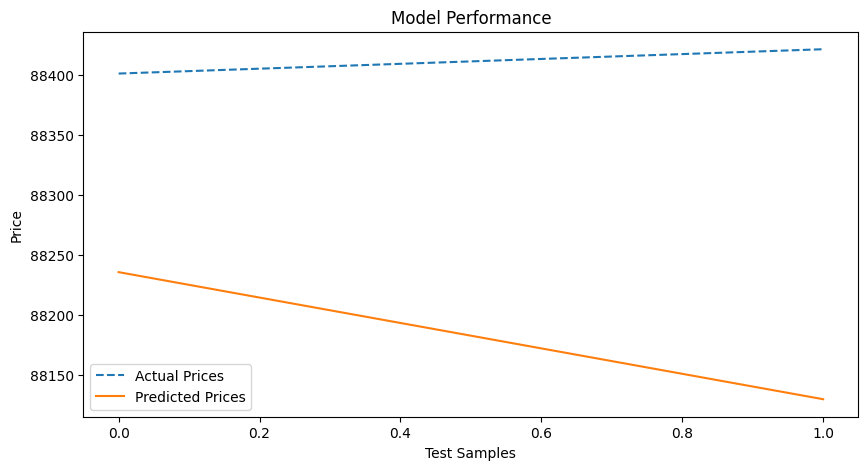

Predicted Bitcoin Price at 2025-03-24 20:30:00: 88189.27099999998
Predicted Bitcoin Price at 2025-03-24 20:45:00: 88200.31799999997
Predicted Bitcoin Price at 2025-03-24 21:00:00: 88200.31799999997
Predicted Bitcoin Price at 2025-03-24 21:15:00: 88200.31799999997


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 2 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=2)).timestamp())
to_timestamp = int(datetime.utcnow().timestamp())

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

headers = {"api_key": api_key}
response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

data_frames = []

if response_oi.status_code == 200:
    response_data_oi = response_oi.json()
    if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
        history_data_oi = response_data_oi[0]["history"]
        df_oi = pd.DataFrame(history_data_oi)
        df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)
        df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
        df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_oi)

# ✅ OHLCV Parameters
params_ohlcv = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp
}

response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

if response_ohlcv.status_code == 200:
    response_data_ohlcv = response_ohlcv.json()
    if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
        history_data_ohlcv = response_data_ohlcv[0]["history"]
        df_ohlcv = pd.DataFrame(history_data_ohlcv)
        df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)
        df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
        df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_ohlcv)

if len(data_frames) == 2:
    df = pd.merge(data_frames[0], data_frames[1], on="Timestamp UTC", how="inner")
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    df.dropna(subset=['Close'], inplace=True)
    X = df[['Open Interest', 'OI High', 'OI Low', 'OI Close', 'Open', 'High', 'Low', 'Volume']]
    y = df['Close'].shift(-1).dropna()
    X = X.iloc[:-1]

    if len(X) == len(y) and len(df) > 1:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        error = mean_absolute_error(y_test, y_pred)
        print(f"Mean Absolute Error: {error}")

        df.loc[df.index[:len(X)], 'Predicted_Close'] = model.predict(X)
        df.to_csv("predicted_bitcoin_prices.csv", index=False)
        print("✅ Predictions saved to 'predicted_bitcoin_prices.csv'")

        latest_prediction = df['Predicted_Close'].dropna().iloc[-1]
        print(f"🚀 Latest Predicted Bitcoin Price: {latest_prediction}")

        # ✅ Plot Learning Curve
        plt.figure(figsize=(10,5))
        plt.plot(y_test.values, label='Actual Prices', linestyle='dashed')
        plt.plot(y_pred, label='Predicted Prices')
        plt.xlabel('Test Samples')
        plt.ylabel('Price')
        plt.title('Model Performance')
        plt.legend()
        plt.show()

        # ✅ Predict Next 1 Hour in 15-min Intervals Iteratively
        future_prices = []
        future_features = df.iloc[-1][['Open Interest', 'OI High', 'OI Low', 'OI Close', 'Open', 'High', 'Low', 'Volume']].values.reshape(1, -1)

        for i in range(4):
            pred_price = model.predict(future_features)[0]
            future_prices.append(pred_price)
            future_features[0][-1] = pred_price  # Update Close price for next prediction

        future_times = [df['Timestamp UTC'].iloc[-1] + timedelta(minutes=15*(i+1)) for i in range(4)]

        for t, p in zip(future_times, future_prices):
            print(f"Predicted Bitcoin Price at {t}: {p}")
    else:
        print("❌ Not enough data after preprocessing or misalignment between X and y.")
else:
    print("❌ Data merging failed.")


✅ Data fetched successfully. Total records: 24
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.5422 - val_loss: 0.7359
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.3885 - val_loss: 0.5777
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.2914 - val_loss: 0.4427
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.2437 - val_loss: 0.3290
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.1780 - val_loss: 0.2383
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.1480 - val_loss: 0.1730
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.1307 - val_loss: 0.1327
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.1155 - val_loss: 0.1102
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.1352 - val_loss: 0.0973
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.1527 - val_loss: 0.0873
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.1227 - val_loss: 0.0794
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 0.1185 - val_loss: 0.0748
Epoch 13

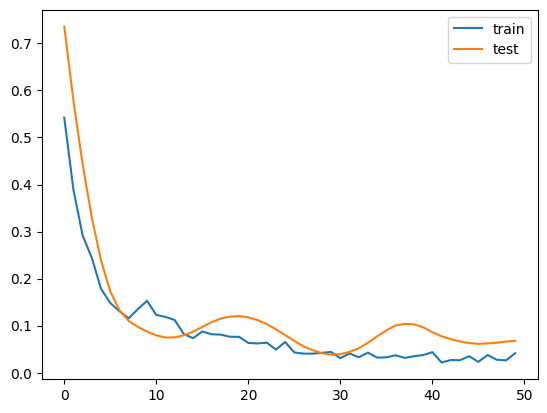

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Bitcoin Price at 2025-03-26 21:45:00: 86955.50564273595
Predicted Bitcoin Price at 2025-03-26 22:00:00: 86863.43792389632
Predicted Bitcoin Price at 2025-03-26 22:15:00: 86808.27200266122
Predicted Bitcoin Price at 2025-03-26 22:30:00: 86752.62129536868


In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 6 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=6)).timestamp())
to_timestamp = int(datetime.utcnow().timestamp())

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

headers = {"api_key": api_key}
response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

data_frames = []

if response_oi.status_code == 200:
    response_data_oi = response_oi.json()
    if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
        history_data_oi = response_data_oi[0]["history"]
        df_oi = pd.DataFrame(history_data_oi)
        df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)
        df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
        df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_oi)

# ✅ OHLCV Parameters
params_ohlcv = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp
}

response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

if response_ohlcv.status_code == 200:
    response_data_ohlcv = response_ohlcv.json()
    if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
        history_data_ohlcv = response_data_ohlcv[0]["history"]
        df_ohlcv = pd.DataFrame(history_data_ohlcv)
        df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)
        df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
        df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_ohlcv)

if len(data_frames) == 2:
    df = pd.merge(data_frames[0], data_frames[1], on="Timestamp UTC", how="inner")
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    df.dropna(subset=['Close'], inplace=True)

    print(f"✅ Data fetched successfully. Total records: {len(df)}")

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[['Open Interest', 'OI High', 'OI Low', 'OI Close', 'Open', 'High', 'Low', 'Volume', 'Close']])

    X, y = [], []
    seq_length = 10

    for i in range(len(scaled_data) - seq_length):
        X.append(scaled_data[i:i+seq_length, :-1])
        y.append(scaled_data[i+seq_length, -1])

    X, y = np.array(X), np.array(y)

    if len(X) == 0 or len(y) == 0:
        raise ValueError("❌ Insufficient data for training. Try fetching more data.")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_length, X.shape[2])),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.1),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.legend()
    plt.show()

    future_predictions = []
    future_input = X[-1].reshape(1, seq_length, X.shape[2])

    for _ in range(4):
        pred = model.predict(future_input)[0][0]
        future_predictions.append(pred)
        new_feature = np.append(future_input[0, 1:, :], np.full((1, X.shape[2]), pred), axis=0).reshape(1, seq_length, X.shape[2])
        future_input = new_feature

    future_prices = scaler.inverse_transform([[0]*8 + [p] for p in future_predictions])[:, -1]
    future_times = [df['Timestamp UTC'].iloc[-1] + timedelta(minutes=15*(i+1)) for i in range(4)]

    for t, p in zip(future_times, future_prices):
        print(f"Predicted Bitcoin Price at {t}: {p}")
else:
    print("❌ Data merging failed.")


✅ Data fetched successfully. Total records: 24
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2958 - val_loss: 0.1920
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.1288 - val_loss: 0.1097
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0888 - val_loss: 0.0707
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0631 - val_loss: 0.0660
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0621 - val_loss: 0.0712
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0939 - val_loss: 0.0661
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.1121 - val_loss: 0.0544
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0862 - val_loss: 0.0440
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0642 - val_loss: 0.0398
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0449 - val_loss: 0.0421
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0556 - val_loss: 0.0478
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0363 - val_loss: 0.0558
Epoch 13/5

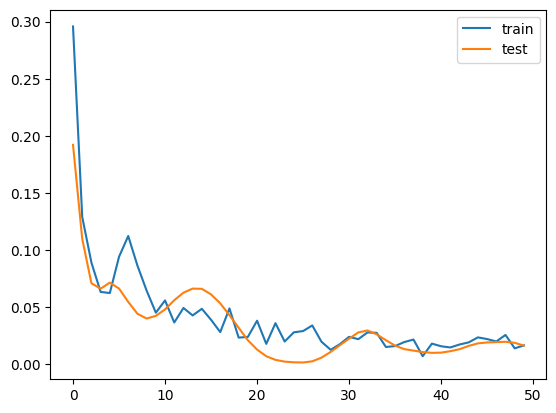

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Bitcoin Price at 2025-03-27 19:00:00: 86535.00580137671
Predicted Bitcoin Price at 2025-03-27 19:15:00: 86489.71776474417
Predicted Bitcoin Price at 2025-03-27 19:30:00: 86451.7424830556
Predicted Bitcoin Price at 2025-03-27 19:45:00: 86424.96336789988


In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

## Indian Timing

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 6 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=6)).timestamp())
to_timestamp = int(datetime.utcnow().timestamp())

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

headers = {"api_key": api_key}
response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

data_frames = []

if response_oi.status_code == 200:
    response_data_oi = response_oi.json()
    if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
        history_data_oi = response_data_oi[0]["history"]
        df_oi = pd.DataFrame(history_data_oi)
        df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)
        df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
        df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_oi)

# ✅ OHLCV Parameters
params_ohlcv = {
    "symbols": "BTCUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp
}

response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

if response_ohlcv.status_code == 200:
    response_data_ohlcv = response_ohlcv.json()
    if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
        history_data_ohlcv = response_data_ohlcv[0]["history"]
        df_ohlcv = pd.DataFrame(history_data_ohlcv)
        df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)
        df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
        df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_ohlcv)

if len(data_frames) == 2:
    df = pd.merge(data_frames[0], data_frames[1], on="Timestamp UTC", how="inner")
    df["Timestamp IST"] = df["Timestamp UTC"] + timedelta(hours=5, minutes=30)
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    df.dropna(subset=['Close'], inplace=True)

    print(f"✅ Data fetched successfully. Total records: {len(df)}")

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[['Open Interest', 'OI High', 'OI Low', 'OI Close', 'Open', 'High', 'Low', 'Volume', 'Close']])

    X, y = [], []
    seq_length = 10

    for i in range(len(scaled_data) - seq_length):
        X.append(scaled_data[i:i+seq_length, :-1])
        y.append(scaled_data[i+seq_length, -1])

    X, y = np.array(X), np.array(y)

    if len(X) == 0 or len(y) == 0:
        raise ValueError("❌ Insufficient data for training. Try fetching more data.")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_length, X.shape[2])),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.legend()
    plt.show()

    future_predictions = []
    future_input = X[-1].reshape(1, seq_length, X.shape[2])

    for _ in range(4):
        pred = model.predict(future_input)[0][0]
        future_predictions.append(pred)
        new_feature = np.append(future_input[0, 1:, :], np.full((1, X.shape[2]), pred), axis=0).reshape(1, seq_length, X.shape[2])
        future_input = new_feature

    future_prices = scaler.inverse_transform([[0]*8 + [p] for p in future_predictions])[:, -1]
    future_times = [df['Timestamp IST'].iloc[-1] + timedelta(minutes=15*(i+1)) for i in range(4)]

    for t, p in zip(future_times, future_prices):
        print(f"Predicted Bitcoin Price at {t}: {p}")
else:
    print("❌ Data merging failed.")


In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

## Indian Timing

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 6 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=6)).timestamp())
to_timestamp = int(datetime.utcnow().timestamp())

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "ETHUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

headers = {"api_key": api_key}
response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

data_frames = []

if response_oi.status_code == 200:
    response_data_oi = response_oi.json()
    if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
        history_data_oi = response_data_oi[0]["history"]
        df_oi = pd.DataFrame(history_data_oi)
        df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)
        df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
        df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_oi)

# ✅ OHLCV Parameters
params_ohlcv = {
    "symbols": "ETHUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp
}

response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

if response_ohlcv.status_code == 200:
    response_data_ohlcv = response_ohlcv.json()
    if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
        history_data_ohlcv = response_data_ohlcv[0]["history"]
        df_ohlcv = pd.DataFrame(history_data_ohlcv)
        df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)
        df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
        df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_ohlcv)

if len(data_frames) == 2:
    df = pd.merge(data_frames[0], data_frames[1], on="Timestamp UTC", how="inner")
    df["Timestamp IST"] = df["Timestamp UTC"] + timedelta(hours=5, minutes=30)
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    df.dropna(subset=['Close'], inplace=True)

    print(f"✅ Data fetched successfully. Total records: {len(df)}")

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[['Open Interest', 'OI High', 'OI Low', 'OI Close', 'Open', 'High', 'Low', 'Volume', 'Close']])

    X, y = [], []
    seq_length = 10

    for i in range(len(scaled_data) - seq_length):
        X.append(scaled_data[i:i+seq_length, :-1])
        y.append(scaled_data[i+seq_length, -1])

    X, y = np.array(X), np.array(y)

    if len(X) == 0 or len(y) == 0:
        raise ValueError("❌ Insufficient data for training. Try fetching more data.")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_length, X.shape[2])),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.legend()
    plt.show()

    future_predictions = []
    future_input = X[-1].reshape(1, seq_length, X.shape[2])

    for _ in range(4):
        pred = model.predict(future_input)[0][0]
        future_predictions.append(pred)
        new_feature = np.append(future_input[0, 1:, :], np.full((1, X.shape[2]), pred), axis=0).reshape(1, seq_length, X.shape[2])
        future_input = new_feature

    future_prices = scaler.inverse_transform([[0]*8 + [p] for p in future_predictions])[:, -1]
    future_times = [df['Timestamp IST'].iloc[-1] + timedelta(minutes=15*(i+1)) for i in range(4)]

    for t, p in zip(future_times, future_prices):
        print(f"Predicted Ethereum Price at {t}: {p}")
else:
    print("❌ Data merging failed.")


✅ Data fetched successfully. Total records: 24
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.6099 - val_loss: 0.2827
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.4544 - val_loss: 0.1630
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.3042 - val_loss: 0.0770
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - loss: 0.1928 - val_loss: 0.0230
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0996 - val_loss: 0.0034
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0606 - val_loss: 0.0205
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.0300 - val_loss: 0.0685
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.0452 - val_loss: 0.1285
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - loss: 0.0620 - val_loss: 0.1694
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0787 - val_loss: 0.1799
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.0769 - val_loss: 0.1647
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - loss: 0.0885 - val_loss: 0.1302
Epo

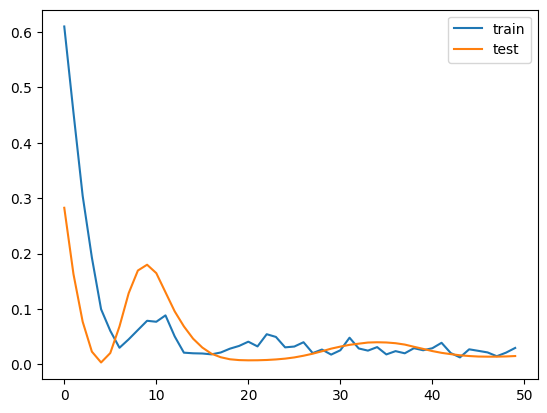

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted BNB Price at 2025-03-28 02:30:00: 638.8756549829245
Predicted BNB Price at 2025-03-28 02:45:00: 638.7865930312872
Predicted BNB Price at 2025-03-28 03:00:00: 638.8088666760922
Predicted BNB Price at 2025-03-28 03:15:00: 638.92238761127


In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

## Indian Timing

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 6 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=6)).timestamp())
to_timestamp = int(datetime.utcnow().timestamp())

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "BNBUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

headers = {"api_key": api_key}
response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

data_frames = []

if response_oi.status_code == 200:
    response_data_oi = response_oi.json()
    if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
        history_data_oi = response_data_oi[0]["history"]
        df_oi = pd.DataFrame(history_data_oi)
        df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)
        df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
        df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_oi)

# ✅ OHLCV Parameters
params_ohlcv = {
    "symbols": "BNBUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp
}

response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

if response_ohlcv.status_code == 200:
    response_data_ohlcv = response_ohlcv.json()
    if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
        history_data_ohlcv = response_data_ohlcv[0]["history"]
        df_ohlcv = pd.DataFrame(history_data_ohlcv)
        df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)
        df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
        df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_ohlcv)

if len(data_frames) == 2:
    df = pd.merge(data_frames[0], data_frames[1], on="Timestamp UTC", how="inner")
    df["Timestamp IST"] = df["Timestamp UTC"] + timedelta(hours=5, minutes=30)
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    df.dropna(subset=['Close'], inplace=True)

    print(f"✅ Data fetched successfully. Total records: {len(df)}")

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[['Open Interest', 'OI High', 'OI Low', 'OI Close', 'Open', 'High', 'Low', 'Volume', 'Close']])

    X, y = [], []
    seq_length = 10

    for i in range(len(scaled_data) - seq_length):
        X.append(scaled_data[i:i+seq_length, :-1])
        y.append(scaled_data[i+seq_length, -1])

    X, y = np.array(X), np.array(y)

    if len(X) == 0 or len(y) == 0:
        raise ValueError("❌ Insufficient data for training. Try fetching more data.")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_length, X.shape[2])),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.legend()
    plt.show()

    future_predictions = []
    future_input = X[-1].reshape(1, seq_length, X.shape[2])

    for _ in range(4):
        pred = model.predict(future_input)[0][0]
        future_predictions.append(pred)
        new_feature = np.append(future_input[0, 1:, :], np.full((1, X.shape[2]), pred), axis=0).reshape(1, seq_length, X.shape[2])
        future_input = new_feature

    future_prices = scaler.inverse_transform([[0]*8 + [p] for p in future_predictions])[:, -1]
    future_times = [df['Timestamp IST'].iloc[-1] + timedelta(minutes=15*(i+1)) for i in range(4)]

    for t, p in zip(future_times, future_prices):
        print(f"Predicted BNB Price at {t}: {p}")
else:
    print("❌ Data merging failed.")


✅ Data fetched successfully. Total records: 24
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.5164 - val_loss: 0.3359
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.3478 - val_loss: 0.2144
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.2306 - val_loss: 0.1197
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1253 - val_loss: 0.0544
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0742 - val_loss: 0.0226
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0285 - val_loss: 0.0276
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0246 - val_loss: 0.0598
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0558 - val_loss: 0.0955
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.1176 - val_loss: 0.1023
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.1084 - val_loss: 0.0866
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0998 - val_loss: 0.0624
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0486 - val_loss: 0.0412
Epo

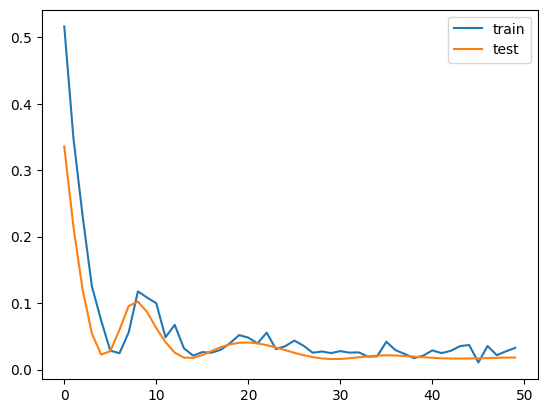

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
❌ Predicted BNB Price at 2025-03-28 03:45:00: 638.2334980541468 - Not Matched
❌ Predicted BNB Price at 2025-03-28 04:00:00: 638.1561001086235 - Not Matched
❌ Predicted BNB Price at 2025-03-28 04:15:00: 638.1881567084789 - Not Matched
❌ Predicted BNB Price at 2025-03-28 04:30:00: 638.3308573418856 - Not Matched


In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

## Indian Timing

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# ✅ Define API parameters (Fetch past 6 hours)
from_timestamp = int((datetime.utcnow() - timedelta(hours=6)).timestamp())
to_timestamp = int(datetime.utcnow().timestamp())

# ✅ Open Interest Parameters
params_oi = {
    "symbols": "BNBUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp,
    "convert_to_usd": "true"
}

headers = {"api_key": api_key}
response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

data_frames = []

if response_oi.status_code == 200:
    response_data_oi = response_oi.json()
    if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
        history_data_oi = response_data_oi[0]["history"]
        df_oi = pd.DataFrame(history_data_oi)
        df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)
        df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
        df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_oi)

# ✅ OHLCV Parameters
params_ohlcv = {
    "symbols": "BNBUSDT_PERP.A",
    "interval": "15min",
    "from": from_timestamp,
    "to": to_timestamp
}

response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

if response_ohlcv.status_code == 200:
    response_data_ohlcv = response_ohlcv.json()
    if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
        history_data_ohlcv = response_data_ohlcv[0]["history"]
        df_ohlcv = pd.DataFrame(history_data_ohlcv)
        df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)
        df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
        df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        data_frames.append(df_ohlcv)

if len(data_frames) == 2:
    df = pd.merge(data_frames[0], data_frames[1], on="Timestamp UTC", how="inner")
    df["Timestamp IST"] = df["Timestamp UTC"] + timedelta(hours=5, minutes=30)
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    df.dropna(subset=['Close'], inplace=True)

    print(f"✅ Data fetched successfully. Total records: {len(df)}")

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[['Open Interest', 'OI High', 'OI Low', 'OI Close', 'Open', 'High', 'Low', 'Volume', 'Close']])

    X, y = [], []
    seq_length = 10

    for i in range(len(scaled_data) - seq_length):
        X.append(scaled_data[i:i+seq_length, :-1])
        y.append(scaled_data[i+seq_length, -1])

    X, y = np.array(X), np.array(y)

    if len(X) == 0 or len(y) == 0:
        raise ValueError("❌ Insufficient data for training. Try fetching more data.")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_length, X.shape[2])),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.legend()
    plt.show()

    future_predictions = []
    future_input = X[-1].reshape(1, seq_length, X.shape[2])

    for _ in range(4):
        pred = model.predict(future_input)[0][0]
        future_predictions.append(pred)
        new_feature = np.append(future_input[0, 1:, :], np.full((1, X.shape[2]), pred), axis=0).reshape(1, seq_length, X.shape[2])
        future_input = new_feature

    future_prices = scaler.inverse_transform([[0]*8 + [p] for p in future_predictions])[:, -1]
    future_times = [df['Timestamp IST'].iloc[-1] + timedelta(minutes=15*(i+1)) for i in range(4)]

    for t, p in zip(future_times, future_prices):
        actual_data = df[(df['Timestamp IST'] >= t) & (df['Timestamp IST'] < t + timedelta(minutes=15))]
        if not actual_data.empty and actual_data['Low'].min() >= p >= actual_data['High'].max():
            print(f"✅ Predicted BNB Price at {t}: {p} - Matched")
        else:
            print(f"❌ Predicted BNB Price at {t}: {p} - Not Matched")
else:
    print("❌ Data merging failed.")

# Schedule the fetch_and_validate function to run every 15 minutes
schedule.every(10).seconds.do(fetch_and_validate)

# Keep the scheduler running
while True:
    schedule.run_pending()
    time.sleep(1)



In [25]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import time
import schedule

## Indian Timing

# ✅ API Endpoints
open_interest_url = "https://api.coinalyze.net/v1/open-interest-history"
ohlcv_url = "https://api.coinalyze.net/v1/ohlcv-history"

# ✅ Your API Key
api_key = "6a1cdca0-79b5-4987-aa7d-8fe6d1eba3a9"

# Global variables for predictions
future_times = []
future_prices = []

def fetch_and_validate():
    from_timestamp = int((datetime.utcnow() - timedelta(hours=6)).timestamp())
    to_timestamp = int(datetime.utcnow().timestamp())

    # ✅ Open Interest Parameters
    params_oi = {
        "symbols": "BNBUSDT_PERP.A",
        "interval": "15min",
        "from": from_timestamp,
        "to": to_timestamp,
        "convert_to_usd": "true"
    }

    headers = {"api_key": api_key}
    response_oi = requests.get(open_interest_url, headers=headers, params=params_oi)

    data_frames = []

    if response_oi.status_code == 200:
        response_data_oi = response_oi.json()
        if response_data_oi and isinstance(response_data_oi, list) and "history" in response_data_oi[0]:
            history_data_oi = response_data_oi[0]["history"]
            df_oi = pd.DataFrame(history_data_oi)
            df_oi.rename(columns={"t": "Timestamp UTC", "o": "Open Interest", "h": "OI High", "l": "OI Low", "c": "OI Close"}, inplace=True)
            df_oi["Timestamp UTC"] = pd.to_datetime(df_oi["Timestamp UTC"], unit="s")
            df_oi["Timestamp IST"] = df_oi["Timestamp UTC"] + timedelta(hours=5, minutes=30)
            data_frames.append(df_oi)

    # ✅ OHLCV Parameters
    params_ohlcv = {
        "symbols": "BNBUSDT_PERP.A",
        "interval": "15min",
        "from": from_timestamp,
        "to": to_timestamp
    }

    response_ohlcv = requests.get(ohlcv_url, headers=headers, params=params_ohlcv)

    if response_ohlcv.status_code == 200:
        response_data_ohlcv = response_ohlcv.json()
        if response_data_ohlcv and isinstance(response_data_ohlcv, list) and "history" in response_data_ohlcv[0]:
            history_data_ohlcv = response_data_ohlcv[0]["history"]
            df_ohlcv = pd.DataFrame(history_data_ohlcv)
            df_ohlcv.rename(columns={"t": "Timestamp UTC", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"}, inplace=True)
            df_ohlcv["Timestamp UTC"] = pd.to_datetime(df_ohlcv["Timestamp UTC"], unit="s")
            df_ohlcv["Timestamp IST"] = df_ohlcv["Timestamp UTC"] + timedelta(hours=5, minutes=30)
            data_frames.append(df_ohlcv)

    if len(data_frames) == 2:
        df = pd.merge(data_frames[0], data_frames[1], on="Timestamp UTC", how="inner")
        df["Timestamp IST"] = df["Timestamp UTC"] + timedelta(hours=5, minutes=30)
        df.ffill(inplace=True)
        df.bfill(inplace=True)
        df.dropna(subset=['Close'], inplace=True)

        print(f"✅ Data fetched successfully. Total records: {len(df)}")

        # Validate Predictions
        check_predictions(df, future_times, future_prices)
    else:
        print("❌ Data merging failed.")

def check_predictions(df, future_times, future_prices):
    for t, p in zip(future_times, future_prices):
        actual_data = df[(df['Timestamp IST'] >= t) & (df['Timestamp IST'] < t + timedelta(minutes=30))]
        if not actual_data.empty:
            if actual_data['Low'].min() <= p <= actual_data['High'].max():
                print(f"✅ At {t}, predicted price {p} is within the actual range.")
            elif actual_data['Low'].min() > p:
                print(f"❌ At {t}, predicted price {p} has crossed below the lowest actual price.")
            elif actual_data['High'].max() < p:
                print(f"❌ At {t}, predicted price {p} has crossed above the highest actual price.")
        else:
            print(f"⚠️ No actual data available for {t}")

# Schedule the fetch_and_validate function to run every 15 minutes
schedule.every(15).minutes.do(fetch_and_validate)

# Keep the scheduler running
while True:
    schedule.run_pending()
    time.sleep(1)


KeyboardInterrupt: 